<a href="https://colab.research.google.com/github/Saiful-2/house-price-prediction/blob/main/notebooks/5_housing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🟩 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

##🟩 2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/ames_housing_cleaned.csv"

df = pd.read_csv(url)

df.shape

(2925, 80)

In [3]:
df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,land_slope,neighborhood,condition_1,condition_2,bldg_type,house_style,overall_qual,overall_cond,year_built,year_remodadd,roof_style,roof_matl,exterior_1st,exterior_2nd,mas_vnr_type,mas_vnr_area,exter_qual,exter_cond,foundation,bsmt_qual,bsmt_cond,bsmt_exposure,bsmtfin_type_1,bsmtfin_sf_1,bsmtfin_type_2,bsmtfin_sf_2,bsmt_unf_sf,total_bsmt_sf,heating,heating_qc,central_air,electrical,1st_flr_sf,2nd_flr_sf,low_qual_fin_sf,gr_liv_area,bsmt_full_bath,bsmt_half_bath,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,kitchen_qual,totrms_abvgrd,functional,fireplaces,fireplace_qu,garage_type,garage_yr_blt,garage_finish,garage_cars,garage_area,garage_qual,garage_cond,paved_drive,wood_deck_sf,open_porch_sf,enclosed_porch,3ssn_porch,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,Ex,NaN,Shed,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,BrkFace,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,Gd,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,Gd,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,Ex,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,BrkFace,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,Ex,NaN,Shed,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


## 🟩 3. Define Target Variable

In [4]:
target = "saleprice"

## 🟩 4. Log Transform Target

In [5]:
df["log_saleprice"] = np.log1p(df[target])

## 🟩 5. Separate Features & Target

In [6]:
X = df.drop(columns=[target])
y = df["log_saleprice"]

## 🟩 6. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🟩 7. Create Evaluation Function

In [8]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"🔹 {name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    print("-"*40)

    return rmse, mae, r2

## 🟩 8. Train Models
### 🔹 8.1 Linear Regression

In [9]:
categorical_cols = X_train.select_dtypes(include='object').columns

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

train_cols = X_train_encoded.columns

# Add missing columns to X_test_encoded and set to 0
missing_in_test = set(train_cols) - set(X_test_encoded.columns)
for c in missing_in_test:
    X_test_encoded[c] = 0

# Remove extra columns from X_test_encoded
extra_in_test = set(X_test_encoded.columns) - set(train_cols)
X_test_encoded = X_test_encoded.drop(columns=list(extra_in_test))

# Ensure the order of columns is the same
X_test_encoded = X_test_encoded[train_cols]

lr = LinearRegression()
lr.fit(X_train_encoded, y_train)

y_pred_lr = lr.predict(X_test_encoded)

lr_metrics = evaluate_model("Linear Regression", y_test, y_pred_lr)

🔹 Linear Regression
RMSE: 1.4930901927474821e-12
MAE : 1.2339485558699472e-12
R2  : 1.0
----------------------------------------


## 🔹 8.2 Ridge Regression

In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_encoded, y_train)

y_pred_ridge = ridge.predict(X_test_encoded)

ridge_metrics = evaluate_model("Ridge Regression", y_test, y_pred_ridge)

🔹 Ridge Regression
RMSE: 0.004402338810656121
MAE : 0.0036406476541767743
R2  : 0.9998878536300106
----------------------------------------


## 🔹 8.3 Lasso Regression

In [11]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_encoded, y_train)

y_pred_lasso = lasso.predict(X_test_encoded)

lasso_metrics = evaluate_model("Lasso Regression", y_test, y_pred_lasso)

🔹 Lasso Regression
RMSE: 0.005111231509732576
MAE : 0.0037608025813877666
R2  : 0.9998488286822879
----------------------------------------


## 🔹 8.4 Decision Tree

In [12]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_encoded, y_train)

y_pred_dt = dt.predict(X_test_encoded)

dt_metrics = evaluate_model("Decision Tree", y_test, y_pred_dt)

🔹 Decision Tree
RMSE: 0.00950373598847042
MAE : 0.0021089859254816226
R2  : 0.9994773547350136
----------------------------------------


## 🔹 8.5 Random Forest

In [13]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_encoded, y_train)

y_pred_rf = rf.predict(X_test_encoded)

rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf)

🔹 Random Forest
RMSE: 0.01045029955677557
MAE : 0.0017546015446498768
R2  : 0.9993680601059552
----------------------------------------


## 🔹 8.6 Gradient Boosting

In [14]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_encoded, y_train)

y_pred_gb = gb.predict(X_test_encoded)

gb_metrics = evaluate_model("Gradient Boosting", y_test, y_pred_gb)

🔹 Gradient Boosting
RMSE: 0.0050041567659224835
MAE : 0.0033636392899929735
R2  : 0.9998550960892455
----------------------------------------


## 🟩 9. Model Comparison

In [15]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_metrics[0], ridge_metrics[0], lasso_metrics[0], dt_metrics[0], rf_metrics[0], gb_metrics[0]],
    "MAE": [lr_metrics[1], ridge_metrics[1], lasso_metrics[1], dt_metrics[1], rf_metrics[1], gb_metrics[1]],
    "R2": [lr_metrics[2], ridge_metrics[2], lasso_metrics[2], dt_metrics[2], rf_metrics[2], gb_metrics[2]]
})

results.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
0,Linear,1.493090e-12,1.233949e-12,1.000000
1,Ridge,4.402339e-03,3.640648e-03,0.999888
5,Gradient Boosting,5.004157e-03,3.363639e-03,0.999855
2,Lasso,5.111232e-03,3.760803e-03,0.999849
3,Decision Tree,9.503736e-03,2.108986e-03,0.999477
4,Random Forest,1.045030e-02,1.754602e-03,0.999368


## 📊 10. Visual Comparison

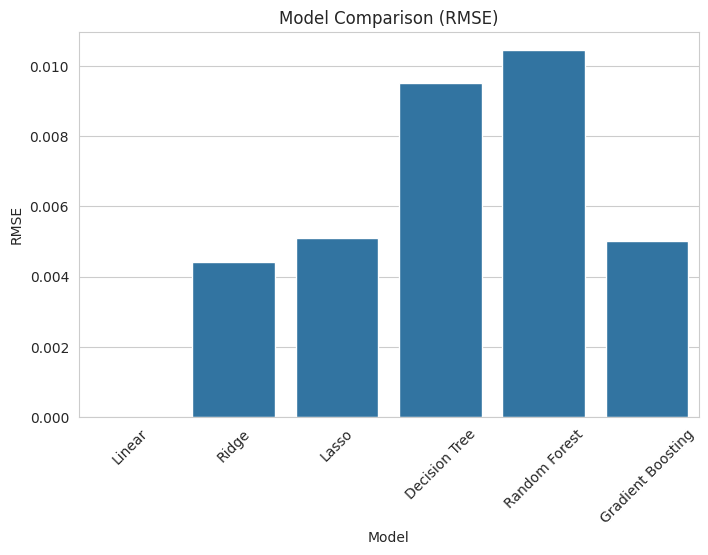

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="RMSE", data=results)
plt.xticks(rotation=45)
plt.title("Model Comparison (RMSE)")
plt.show()

## 📉 11. Predicted vs Actual (Best Model)

 Choosing best model (usually Random Forest or Gradient Boosting)

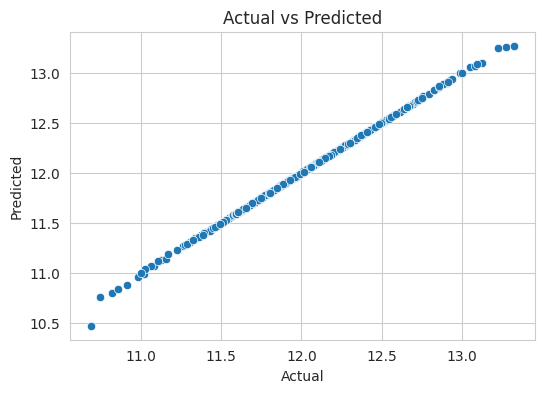

In [17]:
best_model_pred = y_pred_rf  # change if needed

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=best_model_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## 📊 12. Residual Analysis

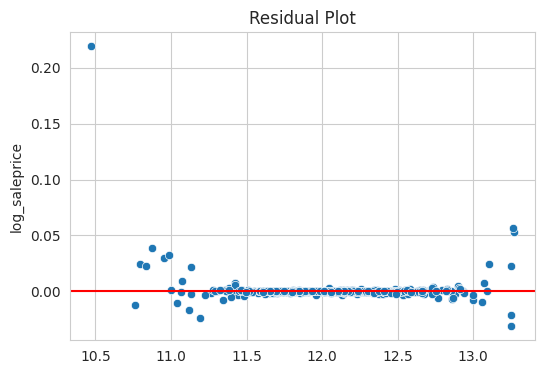

In [18]:
residuals = y_test - best_model_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=best_model_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

## 🧾 13. Final Insights